In [1]:
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
from scipy.integrate import trapezoid

import numpy as np
from numpy.random import normal, uniform

import tqdm

import random
from random import randint

import torch
import torch.nn as nn

Running simulation 1 / 10 ...
Running simulation 2 / 10 ...
Running simulation 3 / 10 ...
Running simulation 4 / 10 ...
Running simulation 5 / 10 ...
Running simulation 6 / 10 ...
Running simulation 7 / 10 ...
Running simulation 8 / 10 ...
Running simulation 9 / 10 ...
Running simulation 10 / 10 ...
Shape of flattened solution vector: (3721,)
Shape of flattened laplacian vector: (3721,)


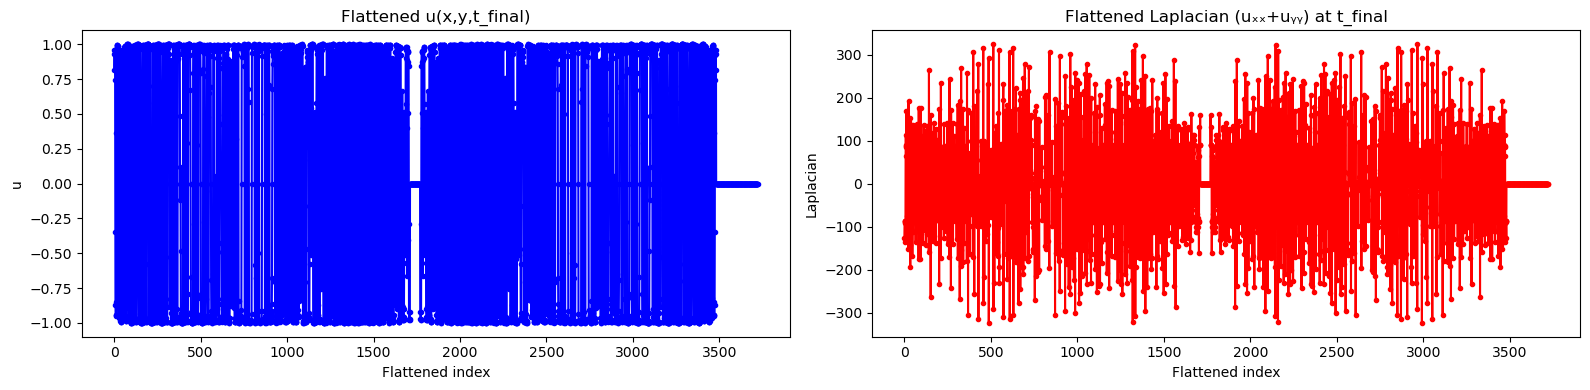

In [3]:
# ===========================================
# PARAMETERS
# ===========================================
epsilon = 0.01             # Parameter in the Allen-Cahn equation
L = 2 * np.pi              # Domain size (both x and y)
Nx = 61                   # Number of grid points in x
Ny = 61                   # Number of grid points in y
dx = L / (Nx - 1)          # Spatial step in x
dy = L / (Ny - 1)          # Spatial step in y

tmax = 5                 # Final time
dt = 1e-2                  # Time step (adjust for stability)
nsteps = int(tmax/dt) + 1  # Total number of time steps

num_inits = 10             # Number of random initial conditions
M = 5                      # Number of sine modes for the random initial condition

# Create spatial grid (for initial condition generation and plotting)
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

# ===========================================
# FUNCTION: Generate Random Initial Condition
# ===========================================
def generate_random_initial(M, X, Y):
    """
    Generate a random function u0(x,y) as a finite sine series:
    
       u0(x,y) = sum_{m=1}^M sum_{n=1}^M A_{m,n} * sin(m * x) * sin(n * y)
       
    This automatically satisfies u0=0 on the boundary (since sin(0)=0, sin(2π)=0).
    """
    u0 = np.zeros_like(X)
    coefficients = np.random.randn(M, M)
    for m in range(1, M+1):
        for n in range(1, M+1):
            u0 += coefficients[m-1, n-1] * np.sin(m * X) * np.sin(n * Y)
    # Scale to have maximum amplitude ~0.25
    u0 = 0.25 * u0 / np.max(np.abs(u0))
    return u0


# ===========================================
# FUNCTION: Custom Flattening with Boundary Last
# ===========================================
def flatten_with_boundary_last(u):
    """
    Flatten a 2D array `u` of shape (Nx, Ny) into a 1D vector of length Nx*Ny,
    with interior points (u[1:-1, 1:-1]) first (row-major order), then the boundary
    points appended in the order:
      - top row u[0,:],
      - bottom row u[-1,:],
      - left column (excluding corners) u[1:-1,0],
      - right column (excluding corners) u[1:-1,-1].
    """
    interior = u[1:-1, 1:-1].flatten()  
    top = u[0, :].flatten()
    bottom = u[-1, :].flatten()
    left = u[1:-1, 0].flatten()
    right = u[1:-1, -1].flatten()
    boundary = np.concatenate((top, bottom, left, right))
    return np.concatenate((interior, boundary))

# ===========================================
# FUNCTION: Solve Allen–Cahn Equation
# ===========================================
def solve_allen_cahn(u0, epsilon, dt, nsteps, dx, dy):
    u = u0.copy()
    sol = np.zeros((nsteps, Nx, Ny))
    sol[0] = u0
    
    # Compute initial Laplacian on interior points
    u_xx = np.zeros_like(u)
    u_yy = np.zeros_like(u)
    u_xx[1:-1, 1:-1] = (u0[2:, 1:-1] - 2*u0[1:-1, 1:-1] + u0[:-2, 1:-1]) / dx**2
    u_yy[1:-1, 1:-1] = (u0[1:-1, 2:] - 2*u0[1:-1, 1:-1] + u0[1:-1, :-2]) / dy**2
    laplacian = u_xx + u_yy
    sol_laplacian = np.zeros((nsteps, Nx, Ny))
    sol_laplacian[0] = laplacian
    
    for t in range(1, nsteps):
        u_old = u.copy()
        u_xx = np.zeros_like(u)
        u_yy = np.zeros_like(u)
        u_xx[1:-1, 1:-1] = (u_old[2:, 1:-1] - 2*u_old[1:-1, 1:-1] + u_old[:-2, 1:-1]) / dx**2
        u_yy[1:-1, 1:-1] = (u_old[1:-1, 2:] - 2*u_old[1:-1, 1:-1] + u_old[1:-1, :-2]) / dy**2
        
        laplacian = u_xx + u_yy
        sol_laplacian[t] = laplacian
        
        # Update the interior with the corresponding interior Laplacian values
        u[1:-1, 1:-1] = u_old[1:-1, 1:-1] + dt * (epsilon**2 * laplacian[1:-1, 1:-1] -
                                                  (u_old[1:-1, 1:-1]**3 - u_old[1:-1, 1:-1]))
        u[0, :] = 0
        u[-1, :] = 0
        u[:, 0] = 0
        u[:, -1] = 0
        
        sol[t] = u
        
    return sol, sol_laplacian

# ===========================================
# PREALLOCATION: Flat data storage
# ===========================================
# We will store the flattened solution and its Laplacian (each flattened vector is of length Nx*Ny)
# The final tensors have shape (num_inits, Nx*Ny, nsteps)
solutions_flat_tensor = np.zeros((num_inits, Nx * Ny, nsteps))
laplacian_flat_tensor = np.zeros((num_inits, Nx * Ny, nsteps))

# ===========================================
# SIMULATIONS
# ===========================================
for sim in range(num_inits):
    print("Running simulation %d / %d ..." % (sim+1, num_inits))
    u0 = generate_random_initial(M, X, Y)
    sol, sol_laplacian = solve_allen_cahn(u0, epsilon, dt, nsteps, dx, dy)
    
    # For each time step, flatten the solution and its laplacian using our custom function
    for t in range(nsteps):
        solutions_flat_tensor[sim, :, t] = flatten_with_boundary_last(sol[t])
        laplacian_flat_tensor[sim, :, t] = flatten_with_boundary_last(sol_laplacian[t])

# ===========================================
# EXAMPLE: Plot the flattened final solution vector for the first simulation
# ===========================================
sim_index = 0
time_index = -1  # last time step
final_solution_flat = solutions_flat_tensor[sim_index, :, time_index]
final_laplacian_flat = laplacian_flat_tensor[sim_index, :, time_index]

print("Shape of flattened solution vector:", final_solution_flat.shape)
print("Shape of flattened laplacian vector:", final_laplacian_flat.shape)

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(final_solution_flat, 'bo-', markersize=3)
plt.title("Flattened u(x,y,t_final)")
plt.xlabel("Flattened index")
plt.ylabel("u")

plt.subplot(1, 2, 2)
plt.plot(final_laplacian_flat, 'ro-', markersize=3)
plt.title("Flattened Laplacian (uₓₓ+uᵧᵧ) at t_final")
plt.xlabel("Flattened index")
plt.ylabel("Laplacian")

plt.tight_layout()
plt.show()

In [4]:
import scipy as sp

In [5]:
import numpy as np

def flatten_collocation_points(X, Y):
    """
    Given 2D arrays X and Y of shape (Nx, Ny) containing the x and y coordinates
    of the grid points, return a 2D array of shape (Nx*Ny, 2) whose rows are the 
    (x, y) coordinates of the grid points arranged in the following order:
      1. Interior points (X[1:-1, 1:-1]) in row-major order.
      2. Top row (X[0, :]), then bottom row (X[-1, :]),
         then left column (excluding corners, i.e. X[1:-1, 0]) 
         and right column (excluding corners, i.e. X[1:-1, -1]).
    """
    # Interior points:
    interior = np.column_stack((X[1:-1, 1:-1].flatten(), Y[1:-1, 1:-1].flatten()))
    
    # Boundary points:
    top = np.column_stack((X[0, :].flatten(), Y[0, :].flatten()))
    bottom = np.column_stack((X[-1, :].flatten(), Y[-1, :].flatten()))
    left = np.column_stack((X[1:-1, 0].flatten(), Y[1:-1, 0].flatten()))
    right = np.column_stack((X[1:-1, -1].flatten(), Y[1:-1, -1].flatten()))
    
    # Concatenate boundary points in the specified order
    boundary = np.concatenate((top, bottom, left, right), axis=0)
    
    # Final ordering: interior points first, then boundary points.
    flattened_coords = np.concatenate((interior, boundary), axis=0)
    return flattened_coords

# Example usage
L = 2*np.pi
Nx, Ny = 61, 61
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

flattened_coords = flatten_collocation_points(X, Y)
print("Shape of flattened_coords:", flattened_coords.shape)
print("First 5 collocation points:\n", flattened_coords[:5])

Shape of flattened_coords: (3721, 2)
First 5 collocation points:
 [[0.10471976 0.10471976]
 [0.20943951 0.10471976]
 [0.31415927 0.10471976]
 [0.41887902 0.10471976]
 [0.52359878 0.10471976]]


In [6]:
#Construct empirical kernel
def compute_empirical_kernels_mixed(u_samples,lap_int):
    K = u_samples @ u_samples.T
    LapK_x = lap_int @ u_samples.T

    LapK_y = u_samples @ lap_int.T

    LapK_xy = lap_int @ lap_int.T


    K_Empirical = np.block([
    [K,      LapK_y],
    [LapK_x, LapK_xy]])

    return K_Empirical

In [77]:
#np.random.seed(0)

N_domain_tot = (Nx-2)*(Ny-2)
N_boundary_tot = Nx*Ny-N_domain_tot
N = N_domain_tot + N_boundary_tot
#Boundary and interior

X_domain_tot = flattened_coords[:N_domain_tot]
X_boundary_tot = flattened_coords[N_domain_tot:]

K_Empirical = np.zeros((N_domain_tot+N,N_domain_tot+N))

#N_solutions = solutions_flat_tensor.shape[0]
N_solutions = 10
laplacian_domain_tensor = laplacian_flat_tensor[:,:N_domain_tot,:]


for i in range(N_solutions):
  K_Empirical = compute_empirical_kernels_mixed(solutions_flat_tensor[i,:,:],laplacian_domain_tensor[i,:,:])

In [78]:
def frob_kernel(A, sigma):
    N, M, T = A.shape
    X = A.reshape(N*T, M).T                    # shape (M, N*T)
    sq_norms = np.sum(X**2, axis=1, keepdims=True)
    D2 = sq_norms + sq_norms.T - 2 * X @ X.T   # pairwise squared Frobenius distances
    K = np.exp(-D2 / (2 * N * T * sigma**2))
    return K

In [79]:
big_tensor = np.concatenate((solutions_flat_tensor,laplacian_domain_tensor),axis=1)

In [80]:
K_Empirical += 0*frob_kernel(big_tensor,0.5)

Shape of the flattened solution vector: (3721,)
Shape of the flattened Laplacian vector: (3721,)


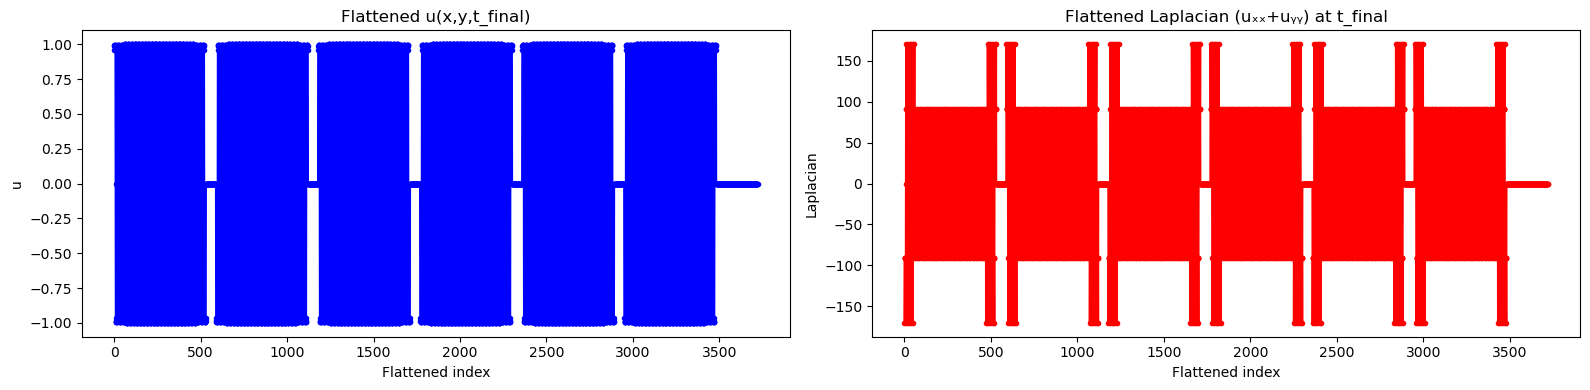

In [81]:
# PARAMETERS
# ===========================================
epsilon = 0.001             # Parameter in the Allen-Cahn equation
L = 2 * np.pi              # Domain size (both x and y)
Nx = 61                   # Number of grid points in x
Ny = 61                   # Number of grid points in y
dx = L / (Nx - 1)          # Spatial step in x
dy = L / (Ny - 1)          # Spatial step in y

tmax = 5                 # Final time
dt = 1e-2                 # Time step (should be small enough for stability)
nsteps = int(tmax/dt) + 1  # Total number of time steps

# ===========================================
# GRID CREATION
# ===========================================
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

# ===========================================
# INITIAL CONDITION
# ===========================================
# Fixed initial condition: u0(x,y) = 0.25 * sin(x) * sin(y)
u0 = 0.25 * np.sin(3*X) * np.sin(3*Y)
# (Note: This function is zero on the boundaries: sin(0)=0 and sin(2π)=0)

# ===========================================
# CUSTOM FLATTENING FUNCTION
# ===========================================
def flatten_with_boundary_last(u):
    """
    Flatten a 2D array u (shape (Nx, Ny)) into a 1D vector of length Nx*Ny.
    The ordering is:
      1. Interior points (u[1:-1, 1:-1]) in row-major order,
      2. Then the boundary points, taken in the order:
           - Top row (u[0, :])
           - Bottom row (u[-1, :])
           - Left column (excluding corners, u[1:-1, 0])
           - Right column (excluding corners, u[1:-1, -1])
    """
    interior = u[1:-1, 1:-1].flatten()
    top = u[0, :].flatten()
    bottom = u[-1, :].flatten()
    left = u[1:-1, 0].flatten()
    right = u[1:-1, -1].flatten()
    boundary = np.concatenate((top, bottom, left, right))
    return np.concatenate((interior, boundary))

# ===========================================
# ALLEN–CAHN SOLVER
# ===========================================
def solve_allen_cahn(u0, epsilon, dt, nsteps, dx, dy):
    """
    Solve the Allen-Cahn equation:
          u_t = epsilon^2*(u_xx + u_yy) - (u^3 - u)
    subject to homogeneous Dirichlet boundary conditions on the domain.
    
    Returns:
      sol           : 3D array of shape (nsteps, Nx, Ny) storing u(x,y,t) at every time step.
      sol_laplacian : 3D array of shape (nsteps, Nx, Ny) storing the Laplacian (u_xx+u_yy).
    """
    # Copy initial condition and allocate arrays for solution and Laplacian
    u = u0.copy()
    sol = np.zeros((nsteps, Nx, Ny))
    sol[0] = u0
    
    # Compute the initial Laplacian (only interior is computed; boundaries remain zero)
    u_xx = np.zeros_like(u)
    u_yy = np.zeros_like(u)
    u_xx[1:-1, 1:-1] = (u0[2:, 1:-1] - 2*u0[1:-1, 1:-1] + u0[:-2, 1:-1]) / dx**2
    u_yy[1:-1, 1:-1] = (u0[1:-1, 2:] - 2*u0[1:-1, 1:-1] + u0[1:-1, :-2]) / dy**2
    laplacian = u_xx + u_yy
    sol_laplacian = np.zeros((nsteps, Nx, Ny))
    sol_laplacian[0] = laplacian
    
    # Time stepping using explicit (forward Euler) method
    for t in range(1, nsteps):
        u_old = u.copy()
        u_xx = np.zeros_like(u)
        u_yy = np.zeros_like(u)
        # Compute second derivatives for interior points
        u_xx[1:-1, 1:-1] = (u_old[2:, 1:-1] - 2*u_old[1:-1, 1:-1] + u_old[:-2, 1:-1]) / dx**2
        u_yy[1:-1, 1:-1] = (u_old[1:-1, 2:] - 2*u_old[1:-1, 1:-1] + u_old[1:-1, :-2]) / dy**2
        
        laplacian = u_xx + u_yy
        sol_laplacian[t] = laplacian
        
        # Update only the interior points using the corresponding interior Laplacian values
        u[1:-1, 1:-1] = u_old[1:-1, 1:-1] + dt * (epsilon**2 * laplacian[1:-1, 1:-1] - 
                                                   (u_old[1:-1, 1:-1]**3 - u_old[1:-1, 1:-1]))
        # Reinforce homogeneous Dirichlet boundary conditions
        u[0, :] = 0
        u[-1, :] = 0
        u[:, 0] = 0
        u[:, -1] = 0
        
        sol[t] = u
        
    return sol, sol_laplacian

# ===========================================
# SOLVE THE PROBLEM
# ===========================================
sol, sol_laplacian = solve_allen_cahn(u0, epsilon, dt, nsteps, dx, dy)

# ===========================================
# FLATTEN THE SOLUTION AND LAPACIAN
# ===========================================
# Each time step is flattened to a vector of length Nx*Ny; the complete temporal evolution
# is stored in matrices of shape ((Nx*Ny) x nsteps).
sol_flat = np.zeros((Nx * Ny, nsteps))
laplacian_flat = np.zeros((Nx * Ny, nsteps))

for t in range(nsteps):
    sol_flat[:, t] = flatten_with_boundary_last(sol[t])
    laplacian_flat[:, t] = flatten_with_boundary_last(sol_laplacian[t])

# ===========================================
# EXAMPLE: PLOT FINAL TIME SOLUTION (FLATTENED)
# ===========================================
final_flat = sol_flat[:, -1]
final_laplacian_flat = laplacian_flat[:, -1]

print("Shape of the flattened solution vector:", final_flat.shape)
print("Shape of the flattened Laplacian vector:", final_laplacian_flat.shape)

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(final_flat, 'bo-', markersize=3)
plt.title("Flattened u(x,y,t_final)")
plt.xlabel("Flattened index")
plt.ylabel("u")

plt.subplot(1, 2, 2)
plt.plot(final_laplacian_flat, 'ro-', markersize=3)
plt.title("Flattened Laplacian (uₓₓ+uᵧᵧ) at t_final")
plt.xlabel("Flattened index")
plt.ylabel("Laplacian")

plt.tight_layout()
plt.show()

In [82]:
#Maximin ordering

def maximin(x):
  init_indices = np.arange(len(x[:,0]))[:,None]

  x = np.concatenate((x,init_indices),axis=1)
  indices = np.copy(init_indices)

  #Select arbitrary index to start (here 0)
  indices[0] = 0
  A = x[indices[0],:-1]

  x = np.delete(x,indices[0],axis=0)

  for i in range(1,len(indices)):
    maximizer = np.argmax(cdist(x[:,:-1],A).min(axis=1))
    indices[i] =x[int(maximizer),:][2]
    A = np.vstack([A,x[int(maximizer),:-1]])
    x = np.delete(x,int(maximizer),axis=0)

  return indices.reshape(-1)

#Permutation map

P = np.zeros(N_domain_tot+N)

grid = flattened_coords

P[:N] = maximin(grid).astype(int)

#Identity map for derivative measurements
ord = np.arange(N_domain_tot)

P[N:] = ord


In [83]:
grid_reordered = grid[P[:N].astype(int)]

In [84]:
Theta = np.zeros((N + N_domain_tot, N + N_domain_tot))

Theta[:N, :N] = K_Empirical[P[:N].astype(int)][:, P[:N].astype(int)]
Theta[N:, N:] = K_Empirical[N:, N:]
Theta[N:, :N] = K_Empirical[N:, P[:N].astype(int)]
Theta[:N, N:] = Theta[N:, :N].T

Theta = Theta / (N *solutions_flat_tensor.shape[2])

trace1 = np.trace(Theta[:N, :N])
trace2 = np.trace(Theta[N:N + N_domain_tot, N:N + N_domain_tot])

ratio = trace2 / trace1

nugget = 1e-8

temp = np.concatenate((np.ones((1, N)), ratio * np.ones((1, N_domain_tot)),), axis=1)
Theta = Theta + nugget * np.diag(temp[0])

# -----------------------------
# 2) Lengthscales
# -----------------------------


#Lengthscale of x
def lengthscale(x):
  lengths = np.ones(len(x[:,0]))
  lengths[0] = float('inf')

  for i in range(1,len(x[:,0])):
    lengths[i] = np.min(cdist(np.array([x[i,:]]),x[:i,:]))
    print(i)

  return lengths

l = lengthscale(grid_reordered)  # lengthscale should return a numpy array
l_extended = np.hstack([l, l[-1] * np.ones(N_domain_tot)])

# -----------------------------
# 3) Sparsity set functions
# -----------------------------
def sparsity_set(x, rho):
    # Reorder x according to maximin(x)
    dist = cdist(x, x)
    # Broadcast the lengthscale computed from x to a full matrix.
    rhol = rho * np.broadcast_to(l, (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

def sparsity_extended(x, rho):
    # extender: indices from P[N:] cast to int
    extender = X_domain_tot
    x = np.vstack([x, extender])
    dist = cdist(x, x)
    rhol = rho * np.broadcast_to(l_extended, (x.shape[0], x.shape[0]))
    arg = np.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]

# -----------------------------
# 4) Sparsity parameter rho and computing sparsity set S
# -----------------------------
rho = 1
S = sparsity_extended(grid_reordered, rho)

def card(j):
    s_j = S[S[:, 1] == j][:, 0]
    cardinality = len(s_j)
    return s_j, cardinality

U = np.zeros((N + N_domain_tot, N + N_domain_tot))

for j in tqdm.tqdm(range(N + N_domain_tot)):
    s_j, cardinality = card(j)
    # Use np.ix_ to index rows and columns from s_j
    Theta_redux = np.linalg.inv(Theta[np.ix_(s_j, s_j)])
    denom = np.sqrt(Theta_redux[-1, -1])
    U[s_j, j] = Theta_redux[:, -1] / denom

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


100%|██████████| 7202/7202 [00:00<00:00, 9486.94it/s] 


In [85]:
flattened_coords.shape

(3721, 2)

In [86]:
#Putting all the pieces together
Permute = np.zeros((N+N_domain_tot,N+N_domain_tot))

combo = np.concatenate((P[:N].astype(int)[:,None],np.arange(N).astype(int)[:,None]),axis=1)

Permute[combo[:,1],combo[:,0]] = 1

Permute[N:,N:] = np.eye(N_domain_tot)

L_ROM = U.T@Permute

In [87]:
L_UT = L_ROM.shape[0]*(L_ROM.shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part is {np.count_nonzero(L_ROM)/L_UT}")

The proportion of nonzero entries in the lower triangular part is 0.0008868068987423588


In [88]:
np.max(L_ROM)

np.float64(10000.0)

In [89]:
#Check L_ROM does not contain inf values
if np.max(L_ROM)==(np.inf or np.nan):
    print("Pick a higher regularization term for empirical kernel matrix")
else:
    print("The empirical kernel is ready to use")

The empirical kernel is ready to use


In [90]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


L_ROM_dense = torch.from_numpy(L_ROM).float().to(device)
indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
values = L_ROM_dense[indices[0], indices[1]]
L_ROM_sparse = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
L_ROM_sparse = L_ROM_sparse.coalesce()

In [91]:
# Convert your original L_ROM (a numpy array) to a PyTorch sparse tensor in float32.

print("Number of nonzeros in L_ROM_sparse:", L_ROM_sparse._nnz())

# -----------------------------------

def J_ROM(v, bdy_g, L, u0, u1, dt=0.01):
    """
    Loss function J_ROM.
    v: tensor of shape (N_domain_tot,)
    bdy_g: tensor of shape (N_boundary_tot,)
    L: sparse matrix of shape (N_total, N_total)
    u0, u1, u2: tensors of shape (N_domain_tot,)
    """
    # Ensure inputs are float32.
    v = v.float()
    bdy_g = bdy_g.float()
    u0 = u0.float()
    u1 = u1.float()

    # Partition v.
    v0 = v[:N_domain_tot]
    # Compute v1.
    v1 = 2/epsilon**2*((v0-u0)/dt-((u0-u0**3)+(v0-v0**3))/2)-u1
    # Construct vv = [v0, bdy_g, v1].
    vv = torch.cat((v0, bdy_g, v1), dim=0)  # shape: (N_total,)
    # Multiply L (sparse) with vv.
    temp = torch.sparse.mm(L, vv.unsqueeze(1))  # shape: (N_total, 1)
    temp = temp.squeeze(1)
    return torch.dot(temp, temp)

def grad_J_ROM_torch(v, bdy_g, L, u0, u1, dt=0.01):
    v = v.clone().detach().requires_grad_(True)
    loss = J_ROM(v, bdy_g, L, u0, u1, dt)
    grad_v, = torch.autograd.grad(loss, v, create_graph=False)
    return grad_v

def Hessian_GN_ROM(v, L, dt=0.01):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    total_rows = N + N_domain_tot  
    mtx = torch.zeros((total_rows, N_domain_tot), dtype=v.dtype, device=v.device)
    v0 = v[:N_domain_tot]
    
    I = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)
    mtx1 = (2/epsilon**2) * (I/dt - 0.5*(I-3*torch.diag(v0)**2))
    
    mtx[:N_domain_tot, :N_domain_tot] = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)
    mtx[N:N+N_domain_tot, :N_domain_tot] = mtx1
    
    S = torch.sparse.mm(L, mtx)
    return 2 * (S.t() @ S)

# -----------------------------
# 4. Gauss–Newton PDE solver using the sparse L_ROM.
def pde_solver_ROM(max_iter, step_size, initial_sol, u0, u1, L_sparse, dt=0.01):
    """
    Gauss–Newton solver for the reduced-order model PDE using a sparse L_ROM.
    """
    bdy_g = torch.zeros(N_boundary_tot, device=initial_sol.device).float()
    sol = initial_sol.clone().detach().float()
    J_hist = []
    
    J_now = J_ROM(sol, bdy_g, L_sparse, u0, u1, dt)
    J_hist.append(J_now.item())
    print('iter = 0', 'J =', J_now.item())
    
    for iter_step in range(1, max_iter+1):
        H = Hessian_GN_ROM(sol, L_sparse, dt)
        grad_val = grad_J_ROM_torch(sol, bdy_g, L_sparse, u0, u1, dt)
        delta = torch.linalg.solve(H, grad_val)
        sol = sol - step_size * delta
        J_now = J_ROM(sol, bdy_g, L_sparse, u0, u1, dt)
        loss_val = J_now.item()
        if not np.isfinite(loss_val):
            raise ValueError(f"Loss is not finite at iteration {iter_step} (loss = {loss_val}). Aborting.")
        J_hist.append(loss_val)
        print(f'iter = {iter_step}, Gauss-Newton step size = {step_size}, J = {loss_val}')

    
    return sol, J_hist, L_sparse

# -----------------------------
# 5. Example usage in a time-stepping loop.
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    L_ROM_dense = torch.from_numpy(L_ROM).float().to(device)
    indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
    values = L_ROM_dense[indices[0], indices[1]]
    L_ROM_sparse = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
    L_ROM_sparse = L_ROM_sparse.coalesce()
    
    # Use our global parameters from above.
    print("Expected L_ROM shape:", (N + N_domain_tot, N + N_domain_tot))
    
    # Example initial solution vector v of shape (N_domain_tot,)
    initial_sol = torch.randn(N_domain_tot, dtype=torch.float32, device=device)

    max_iter = 1
    step_size = 1

    M_t = 106
    dt = 5/(M_t-1)

    # u_approx will store solutions over time, shape: (N_domain_tot, M_t)
    u_approx = torch.zeros((N_domain_tot, M_t), dtype=torch.float32, device=device)
    
    # Suppose X_domain_tot is defined as a NumPy array for the domain.
    # For example:
    X_domain_tot = grid[:N_domain_tot]
    torch_X = torch.from_numpy(X_domain_tot)[:,0].float().to(device)
    torch_Y = torch.from_numpy(X_domain_tot)[:,1].float().to(device)


    u_approx[:N_domain_tot, 0] = 0.25*torch.sin(3*torch_X)*torch.sin(3*torch_Y)
    
    # Set initial u0, u1, u2 from the first time snapshot.
    u0 = u_approx[:N_domain_tot, 0].clone()
    u1 = -2*u_approx[:N_domain_tot,0]
    
    for i in tqdm.tqdm(range(M_t-1)):
        old_u0 = u0.clone()
        old_u1 = u1.clone()
        initial_sol = u_approx[:, i].clone()
        u_next, J_hist, L_Empirical = pde_solver_ROM(max_iter, step_size, initial_sol, u0, u1, L_ROM_sparse, dt=dt)
        u_approx[:, i+1] = u_next.clone()
        u0 = u_approx[:N_domain_tot, i+1].clone()
        u1 =  2/epsilon**2*((u0-old_u0)/dt-((old_u0-old_u0**3)+(u0-u0**3))/2)-old_u1

    # Optionally, do something with u_approx, e.g. plot or save.

Number of nonzeros in L_ROM_sparse: 23001
Expected L_ROM shape: (7202, 7202)


  0%|          | 0/105 [00:00<?, ?it/s]

iter = 0 J = 3.0633685876002e+17


  1%|          | 1/105 [00:00<00:19,  5.28it/s]

iter = 1, Gauss-Newton step size = 1, J = 5871143936.0
iter = 0 J = 3.335545819108475e+17


...

iter = 1, Gauss-Newton step size = 1, J = 22055766016.0
iter = 0 J = 2.1922872435933184e+16
iter = 1, Gauss-Newton step size = 1, J = 21362137088.0
iter = 0 J = 1.8677369661292544e+16


 98%|█████████▊| 103/105 [00:18<00:00,  5.79it/s]

iter = 1, Gauss-Newton step size = 1, J = 20853854208.0
iter = 0 J = 1.5886409718038528e+16
iter = 1, Gauss-Newton step size = 1, J = 20484546560.0
iter = 0 J = 1.3494978370076672e+16


100%|██████████| 105/105 [00:18<00:00,  5.60it/s]

iter = 1, Gauss-Newton step size = 1, J = 20208603136.0
iter = 0 J = 1.1452955496546304e+16
iter = 1, Gauss-Newton step size = 1, J = 20020799488.0


In [92]:
final_approx = u_approx.cpu().detach().numpy()[:,-1]
final_true = final_flat[:N_domain_tot]
#plt.title('')

In [93]:
y

array([0.        , 0.10471976, 0.20943951, 0.31415927, 0.41887902,
       0.52359878, 0.62831853, 0.73303829, 0.83775804, 0.9424778 ,
       1.04719755, 1.15191731, 1.25663706, 1.36135682, 1.46607657,
       1.57079633, 1.67551608, 1.78023584, 1.88495559, 1.98967535,
       2.0943951 , 2.19911486, 2.30383461, 2.40855437, 2.51327412,
       2.61799388, 2.72271363, 2.82743339, 2.93215314, 3.0368729 ,
       3.14159265, 3.24631241, 3.35103216, 3.45575192, 3.56047167,
       3.66519143, 3.76991118, 3.87463094, 3.97935069, 4.08407045,
       4.1887902 , 4.29350996, 4.39822972, 4.50294947, 4.60766923,
       4.71238898, 4.81710874, 4.92182849, 5.02654825, 5.131268  ,
       5.23598776, 5.34070751, 5.44542727, 5.55014702, 5.65486678,
       5.75958653, 5.86430629, 5.96902604, 6.0737458 , 6.17846555,
       6.28318531])

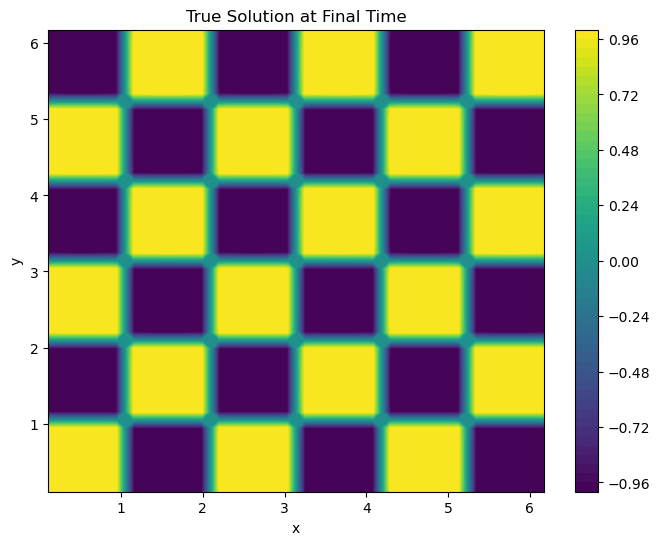

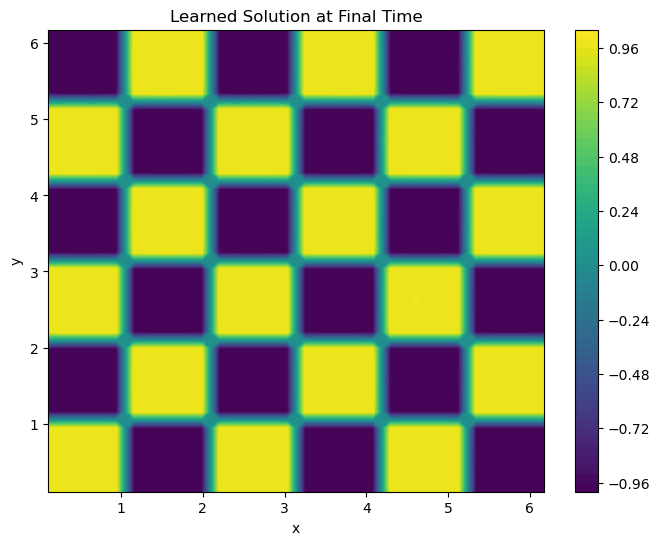

In [94]:
u_final = final_true.reshape((Nx-2,Ny-2))
u_approx = final_approx.reshape((Nx-2,Ny-2))


X, Y = np.meshgrid(x[1:-1], y[1:-1])

plt.figure(figsize=(8, 6))
# Use contourf or pcolormesh to display the 2D field.
cp = plt.contourf(X, Y, u_final, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Solution at Final Time')
plt.show()

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X, Y, u_approx, levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Learned Solution at Final Time')
plt.show()

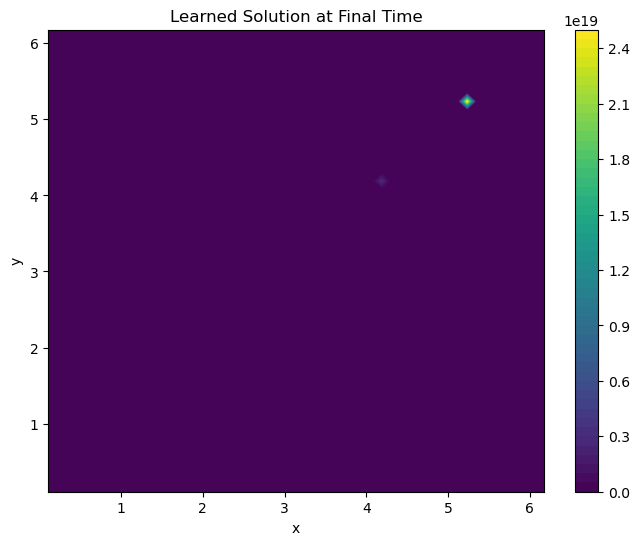

In [95]:
plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X, Y, np.abs(u_approx-u_final)/np.abs(u_final), levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Learned Solution at Final Time')
plt.show()

In [96]:
np.linalg.norm(final_true-final_approx)/np.linalg.norm(final_true)

np.float64(0.001935429128198945)

In [ ]:
0.001935429128198945

In [ ]:
0.0006830659742649235